<a href="https://colab.research.google.com/github/Elnathan9414/machine_learning/blob/main/Assignment4_Josue_Mbondo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 – CV Model Deployment and Inference Pipeline

**Course:** DA3C (hCmpVsn) – Computer Vision

**Student:** Josue Elnathan Mbondo

**Program:** Data Analysis & AI Specialist

**INstructor name:** Mohamed Ghori




## 1. Project Overview

This assignment demonstrates how a trained computer vision model can be deployed into a reproducible inference environment using Docker.

The model was developed during Assignment 3 using the Breast Ultrasound Images Dataset (BUSI). Its purpose is to classify breast ultrasound images into one of three diagnostic categories:

* **Benign**
* **Malignant**
* **Normal**

Rather than retraining the model, this assignment focuses on exporting the trained model, building an inference pipeline, packaging the application inside a Docker container, and demonstrating reproducible predictions on new ultrasound images.



## 2. Objective

The objectives of this assignment are to:

* Export the trained TensorFlow model in a reproducible format.
* Load the saved model for inference.
* Build a clean preprocessing and prediction pipeline.
* Deploy the model inside a Docker container.
* Demonstrate predictions on sample breast ultrasound images.
* Document the deployment workflow and execution instructions.

The deployment is designed to run on CPU using Docker Desktop on Windows 11.


## 3. Import Required Libraries



In [1]:
# ============================================================
# Import Libraries and Setup
# ============================================================

import os
import json
import random
import shutil
from datetime import datetime
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import glob


from PIL import Image

import tensorflow as tf

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Section 1 : Load model

### 1.1 Upload Trained Model from Assignment 3

The trained model from Assignment 3 is loaded into this notebook from its exported Keras model file. This allows the deployment workflow to use the trained model without repeating the training process.

In [2]:
# ============================================================
# Upload Trained Model from Assignment 3
# ============================================================

uploaded = files.upload()

Saving BUSI_MobileNetV2_Assignment3.keras to BUSI_MobileNetV2_Assignment3.keras


In [3]:
# ============================================================
# Load Trained Model
# ============================================================

MODEL_SOURCE = "BUSI_MobileNetV2_Assignment3.keras"

model = tf.keras.models.load_model(MODEL_SOURCE)

print("Model loaded successfully.")
print("Model source:", MODEL_SOURCE)

Model loaded successfully.
Model source: BUSI_MobileNetV2_Assignment3.keras


### 2.2.Verify Loaded Model

In [4]:
# ============================================================
# Verify Loaded Model
# ============================================================

model.summary()

Model: "MobileNetV2_BUSI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,681,675 (17.86 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,419,848 (9.23 MB)

### 1.3 Model Versioning

In [5]:
# ============================================================
# Model Versioning
#
# ============================================================

# Create Version Directory

base_dir = "model_registry"
os.makedirs(base_dir, exist_ok=True)

version = datetime.now().strftime("v_%Y%m%d_%H%M%S")
model_dir = os.path.join(base_dir, version)

os.makedirs(model_dir)

print("Model version:", version)

model_save_path = os.path.join(
    model_dir,
    "saved_model.keras"
)

Model version: v_20260918_145017


### 1.4 Save Full Model (.keras format)

In [6]:
# ============================================================
# Save Full Model (.keras format)
# ============================================================

# Saves architecture, weights, optimizer state,
# and model configuration.

model.save(model_save_path)

print("Model saved to:", model_save_path)

Model saved to: model_registry/v_20260918_145017/saved_model.keras


### 1.5 Save Metadata

In [7]:
# ============================================================
# Save Metadata (Critical in Production)
# ============================================================

metadata = {
    "version": version,
    "img_size": 224,
    "num_classes": 3,
    "class_names": ["normal", "benign", "malignant"],
    "framework": "TensorFlow",
    "tf_version": tf.__version__,
    "date_saved": str(datetime.now())
}

with open(
    os.path.join(model_dir, "metadata.json"),
    "w"
) as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved.")

Metadata saved.


In [8]:
# ============================================================
# Verify Model Registry
# ============================================================

print("Files saved in model version directory:")

for file in os.listdir(model_dir):
    print("-", file)

Files saved in model version directory:
- metadata.json
- saved_model.keras


### Model Export Documentation

#### Model Information

| Property | Description |
|---|---|
| Model Name | MobileNetV2 BUSI Classifier |
| Model Version | The version is generated automatically using the timestamp |
| Framework | TensorFlow / Keras |
| Input Shape | 224 × 224 × 3 |
| Number of Classes | 3 |
| Output Format | Softmax probabilities for Normal, Benign, and Malignant |

#### Input and Preprocessing Requirements

The model was trained using breast ultrasound images from the BUSI dataset.

The preprocessing pipeline includes:

1. Reading the PNG ultrasound image.
2. Converting the original image to grayscale.
3. Resizing the image to 224 × 224 pixels.
4. Normalizing pixel values to the [0, 1] range.
5. Converting the grayscale image to three channels (RGB) before passing it to MobileNetV2.

The deployed inference pipeline must apply the same preprocessing steps used during model development.

### Output Format

The model uses a three-class softmax output. The model returns one probability for each class:

- Normal
- Benign
- Malignant

The predicted class is the class with the highest probability.

##Section  2. Inference Pipeline

The inference pipeline prepares new breast ultrasound images for prediction using the trained and versioned MobileNetV2 model.

The pipeline follows the same preprocessing requirements documented in the Model Export section:

1. Read the input PNG image.
2. Convert the image to grayscale.
3. Resize the image to 224 × 224 pixels.
4. Normalize pixel values to the [0, 1] range.
5. Convert the grayscale image to RGB because the trained MobileNetV2 model expects three input channels.
6. Generate class probabilities using the trained model.
7. Return the predicted class and prediction probabilities.

### 2.1  Load Versioned Model

In [9]:
# ============================================================
# Load Versioned Model
# ============================================================

versioned_model = tf.keras.models.load_model(
    model_save_path
)

print("Versioned model loaded successfully.")

Versioned model loaded successfully.


In [10]:
# ============================================================
# Load Metadata
# ============================================================

metadata_path = os.path.join(
    model_dir,
    "metadata.json"
)

with open(metadata_path, "r") as f:
    metadata = json.load(f)

IMG_SIZE = metadata["img_size"]
CLASS_NAMES = metadata["class_names"]

print("Model version:", metadata["version"])
print("Image size:", IMG_SIZE)
print("Classes:", CLASS_NAMES)

Model version: v_20260918_145017
Image size: 224
Classes: ['normal', 'benign', 'malignant']


### 2.2 Inference Image Preprocessing

In [11]:
# ============================================================
# Inference Image Preprocessing
# ============================================================

def preprocess_image(image_path):
    """
    Preprocess one BUSI ultrasound image for inference.

    Steps:
    - Read image
    - Convert to grayscale
    - Resize to IMG_SIZE x IMG_SIZE
    - Normalize pixel values to [0, 1]
    - Convert grayscale to RGB
    - Add batch dimension
    """

    # Read image
    image = Image.open(image_path)

    # Convert to grayscale
    image = image.convert("L")

    # Resize
    image = image.resize(
        (IMG_SIZE, IMG_SIZE)
    )

    # Convert to NumPy array
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize
    image_array = image_array / 255.0

    # Add channel dimension: (224, 224) -> (224, 224, 1)
    image_array = np.expand_dims(
        image_array,
        axis=-1
    )

    # Convert grayscale to RGB:
    # (224,224,1) -> (224,224,3)
    image_array = np.repeat(
        image_array,
        3,
        axis=-1
    )

    # Add batch dimension:
    # (224,224,3) -> (1,224,224,3)
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    return image_array

### 2.3 Prediction Function

In [12]:
# ============================================================
# Prediction Function
# ============================================================

def predict_image(image_path, model):
    """
    Predict the class of one breast ultrasound image.

    Returns:
        dictionary containing:
        - predicted_class
        - confidence
        - probabilities
    """

    # Preprocess image
    image_array = preprocess_image(image_path)

    # Model prediction
    predictions = model.predict(
        image_array,
        verbose=0
    )

    probabilities = predictions[0]

    # Highest-probability class
    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = float(
        probabilities[predicted_index]
    )

    # Create probability dictionary
    probability_dict = {
        CLASS_NAMES[i]: float(probabilities[i])
        for i in range(len(CLASS_NAMES))
    }

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": probability_dict
    }

def predict_images(image_paths, model):
    """
    Predict the class of a batch of breast ultrasound images.

    Returns:
        list of dictionaries, each containing:
        - image (original image path)
        - predicted_class
        - confidence
        - probabilities
    """
    batch_predictions = []
    for img_path in image_paths:
        result = predict_image(img_path, model)
        result["image"] = img_path  # Add original image path to result
        batch_predictions.append(result)
    return batch_predictions

In [13]:
# ============================================================
# Download / load the BUSI dataset
# ============================================================

# Download dataset from Kaggle
kaggle_path = kagglehub.dataset_download(
    "sabahesaraki/breast-ultrasound-images-dataset"
)

print("Kaggle dataset location:")
print(kaggle_path)

# Original BUSI dataset folder
source_dataset_root = os.path.join(
    kaggle_path,
    "Dataset_BUSI_with_GT"
)

# Store the initial current working directory (e.g., '/content' in Colab)
# This is where the 'model_registry' is initially created.
current_notebook_root_dir = os.getcwd()

# Define the local project directory. For local execution, this will typically
# be the directory containing your notebook, or a sub-directory you want to create.
PROJECT_DIR = "Assignment4" # Or os.path.abspath('.') if notebook is in the root project folder
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR) # Change to project directory for consistent relative paths
print(f"Project directory set to: {os.getcwd()}")

DATA_DIR = os.path.join(os.getcwd(), "data") # Now relative to PROJECT_DIR

os.makedirs(DATA_DIR, exist_ok=True)

# Local copy of the dataset
destination_dataset = os.path.join(
    DATA_DIR,
    "Dataset_BUSI_with_GT"
)

# Copy dataset only if it does not already exist
if not os.path.exists(destination_dataset):
    shutil.copytree(source_dataset_root, destination_dataset)
    print("\n Dataset copied successfully.")
else:
    print("\n Dataset already exists locally.")

print("\nLocal dataset:")
print(destination_dataset)

100%|██████████| 195M/195M [00:01<00:00, 151MB/s]

Extracting files...


Kaggle dataset location:
/root/.cache/kagglehub/datasets/sabahesaraki/breast-ultrasound-images-dataset/versions/1
Project directory set to: /content/Assignment4

 Dataset copied successfully.

Local dataset:
/content/Assignment4/data/Dataset_BUSI_with_GT


In [14]:
# ============================================================
# Check Assignment 4 Dataset
# ============================================================

DATA_DIR = "/content/Assignment4/data"

print("Contents of data directory:")
print(os.listdir(DATA_DIR))

Contents of data directory:
['Dataset_BUSI_with_GT']


In [15]:
# ============================================================
# Locate BUSI Class Directories
# ============================================================

for root, dirs, files in os.walk(DATA_DIR):

    class_dirs = [
        d for d in dirs
        if d.lower() in ["normal", "benign", "malignant"]
    ]

    if class_dirs:
        print("Class directories found in:")
        print(root)
        print(class_dirs)
        break

Class directories found in:
/content/Assignment4/data/Dataset_BUSI_with_GT
['normal', 'malignant', 'benign']


In [16]:
# ============================================================
# Create Sample Images Directory
# ============================================================

sample_dir = "sample_images"
os.makedirs(sample_dir, exist_ok=True)

print("Sample images directory created:", sample_dir)

Sample images directory created: sample_images


In [17]:
for class_name in ["normal", "benign", "malignant"]:

    # Correct the path to include the 'Dataset_BUSI_with_GT' subdirectory
    # The 'destination_dataset' variable holds the correct path
    images = glob.glob(
        f"{destination_dataset}/{class_name}/*.png"
    )

    # Ensure the list is not empty before attempting to access an element
    if not images:
        print(f"Warning: No images found for class: {class_name} at {destination_dataset}/{class_name}/*.png")
        continue

    source_image = images[10]

    destination_image = os.path.join(
        sample_dir,
        f"{class_name}_sample.png"
    )

    shutil.copy(source_image, destination_image)

    print(f"{class_name}: {destination_image}")

normal: sample_images/normal_sample.png
benign: sample_images/benign_sample.png
malignant: sample_images/malignant_sample.png


In [18]:
# ============================================================
# Example Inference
# ============================================================

sample_image = "sample_images/benign_sample.png"

result = predict_image(
    sample_image,
    versioned_model
)

print("Prediction:", result["predicted_class"])
print("Confidence:", f"{result['confidence']:.2%}")

print("\nProbabilities:")

for class_name, probability in result["probabilities"].items():
    print(f"{class_name}: {probability:.2%}")

Prediction: malignant
Confidence: 61.75%

Probabilities:
normal: 4.42%
benign: 33.83%
malignant: 61.75%


### 2.4 Prediction visualization

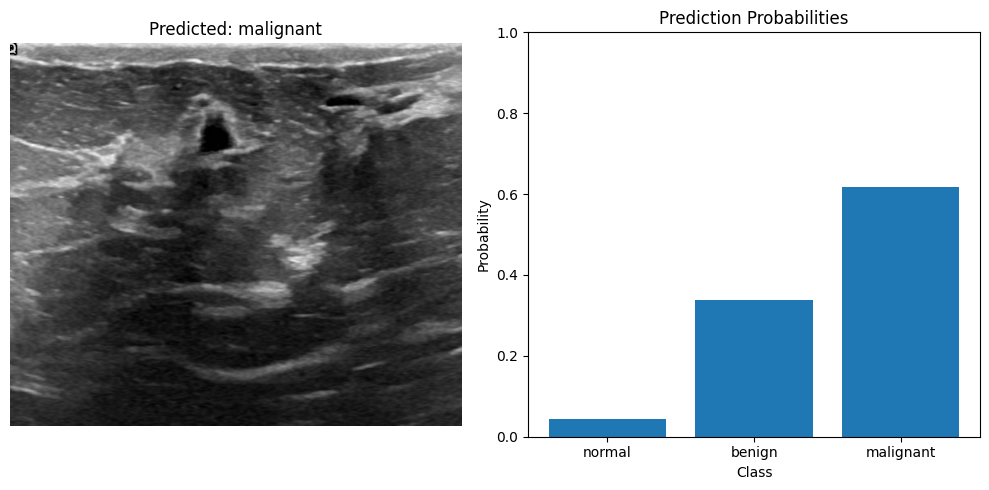

In [19]:
# ============================================================
# Prediction Visualization
# ============================================================

image = Image.open(sample_image).convert("L")

plt.figure(figsize=(10, 5))

# Display image
plt.subplot(1, 2, 1)

plt.imshow(image, cmap="gray")
plt.title(
    f"Predicted: {result['predicted_class']}"
)
plt.axis("off")

# Display probabilities
plt.subplot(1, 2, 2)

classes = list(result["probabilities"].keys())
probabilities = list(result["probabilities"].values())

plt.bar(classes, probabilities)

plt.xlabel("Class")
plt.ylabel("Probability")
plt.title("Prediction Probabilities")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Batch Inference
# ============================================================

sample_images = [
    "sample_images/normal_sample.png",
    "sample_images/benign_sample.png",
    "sample_images/malignant_sample.png"
]

batch_results = predict_images(
    sample_images,
    versioned_model
)

for result in batch_results:

    print("\nImage:", result["image"])
    print("Prediction:", result["predicted_class"])
    print("Confidence:", f"{result['confidence']:.2%}")

    for class_name, probability in result["probabilities"].items():
        print(f"  {class_name}: {probability:.2%}")


Image: sample_images/normal_sample.png
Prediction: normal
Confidence: 58.12%
  normal: 58.12%
  benign: 15.94%
  malignant: 25.94%

Image: sample_images/benign_sample.png
Prediction: malignant
Confidence: 61.75%
  normal: 4.42%
  benign: 33.83%
  malignant: 61.75%

Image: sample_images/malignant_sample.png
Prediction: malignant
Confidence: 69.77%
  normal: 25.77%
  benign: 4.46%
  malignant: 69.77%


 Inference Observation

The inference pipeline successfully processes individual BUSI ultrasound images and returns class probabilities.

The sample results also demonstrate that the trained model can produce incorrect predictions. In particular, the malignant sample in this demonstration was classified as benign. This is consistent with the model's limitations observed during Assignment 3, where the malignant class achieved a recall of 70% on the test set.

These results are presented to demonstrate the inference pipeline and should not be interpreted as a clinical diagnosis.

## Section 3 — REST API Deployment with FastAPI

### 3.1 REST API Deployment (local)

The trained and versioned computer vision model is exposed through a local REST API using FastAPI.

The API accepts a breast ultrasound image, applies the same preprocessing used by the inference pipeline, runs the trained model, and returns the predicted class and class probabilities in JSON format.

The model is loaded once when the API starts. Model configuration and class information are retrieved from the versioned `metadata.json` file.

In [21]:
# ============================================================
# Install FastAPI Dependencies
# ============================================================

!pip install fastapi uvicorn python-multipart

### 3.2 Create server.py

In [22]:
# ============================================================
# Create server.py
# ============================================================

server_code = r'''
from fastapi import FastAPI, UploadFile, File
import tensorflow as tf
import numpy as np
from PIL import Image
import io
import os
import json


app = FastAPI(
    title="BUSI MobileNetV2 Inference API",
    version="1.0"
)


# ============================================================
# Model Configuration
# ============================================================

MODEL_DIR = os.environ.get(
    "MODEL_DIR",
    "model_registry"
)


# When MODEL_DIR points to the root registry, use the
# latest versioned directory.
if os.path.isdir(MODEL_DIR) and os.path.exists(
    os.path.join(MODEL_DIR, "saved_model.keras")
):
    VERSION_DIR = MODEL_DIR
else:
    versions = sorted(
        [
            d for d in os.listdir(MODEL_DIR)
            if os.path.isdir(os.path.join(MODEL_DIR, d))
        ]
    )

    if not versions:
        raise FileNotFoundError(
            "No model version found in model_registry."
        )

    VERSION_DIR = os.path.join(
        MODEL_DIR,
        versions[-1]
    )


# ============================================================
# Load Model
# ============================================================

MODEL_PATH = os.path.join(
    VERSION_DIR,
    "saved_model.keras"
)

model = tf.keras.models.load_model(
    MODEL_PATH
)


# ============================================================
# Load Metadata
# ============================================================

METADATA_PATH = os.path.join(
    VERSION_DIR,
    "metadata.json"
)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

IMG_SIZE = metadata["img_size"]
CLASS_NAMES = metadata["class_names"]


# ============================================================
# Image Preprocessing
# ============================================================

def preprocess_image(file_bytes):

    img = Image.open(
        io.BytesIO(file_bytes)
    ).convert("L")

    img = img.resize(
        (IMG_SIZE, IMG_SIZE)
    )

    img_array = np.array(
        img,
        dtype=np.float32
    ) / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=-1
    )

    img_array = np.repeat(
        img_array,
        3,
        axis=-1
    )

    return np.expand_dims(
        img_array,
        axis=0
    )


# ============================================================
# Health Check
# ============================================================

@app.get("/")
def root():
    return {
        "service": "BUSI MobileNetV2 Inference API",
        "model_version": metadata["version"],
        "classes": CLASS_NAMES
    }


# ============================================================
# Prediction Endpoint
# ============================================================

@app.post("/predict/")
async def predict(
    file: UploadFile = File(...)
):

    bytes_data = await file.read()

    img_array = preprocess_image(
        bytes_data
    )

    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(predictions)
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = float(
        predictions[predicted_index]
    )

    probabilities = {
        CLASS_NAMES[i]: float(predictions[i])
        for i in range(len(CLASS_NAMES))
    }

    return {
        "model_version": metadata["version"],
        "prediction": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities
    }
'''

In [23]:
server_path = os.path.join(
    os.getcwd(), # This will be the PROJECT_DIR (e.g., 'Assignment4')
    "server.py"
)

with open(server_path, "w") as f:
    f.write(server_code)

print("server.py created:", server_path)

server.py created: /content/Assignment4/server.py


In [24]:
# ============================================================
# Prepare Model Registry for FastAPI
# ============================================================


# The original 'model_registry' was created in the initial notebook root directory (e.g., '/content/model_registry').
# We use 'current_notebook_root_dir' saved earlier to reference it.
source_registry = os.path.join(current_notebook_root_dir, "model_registry")
target_registry = os.path.join(os.getcwd(), "model_registry") # Copy into the current PROJECT_DIR

if not os.path.exists(target_registry):
    shutil.copytree(
        source_registry,
        target_registry
    )
    print("Model registry copied successfully.")
else:
    print("Model registry already exists in Assignment4.")

print("Registry contents:")
for item in os.listdir(target_registry):
    print("-", item)

Model registry copied successfully.
Registry contents:
- v_20260918_145017


In [25]:
import nest_asyncio, threading, uvicorn, importlib.util, time
nest_asyncio.apply()  # lets uvicorn's event loop run alongside Colab's own

# Reuse the exact server.py we already wrote for Option A, instead of
# copy-pasting the FastAPI app a second time.
spec = importlib.util.spec_from_file_location("server", "server.py")
server_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(server_module)
app = server_module.app


def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")


server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)  # give it a moment to finish starting up

print("Server should now be running in the background at http://127.0.0.1:8000")

Server should now be running in the background at http://127.0.0.1:8000


### 3.3 Test FastAPI Prediction Endpoint

In [26]:
# ============================================================
# Test FastAPI Prediction Endpoint
# ============================================================

import requests

# The sample images are now located in 'sample_images' within the PROJECT_DIR
file_path = os.path.join("sample_images", "malignant_sample.png")

with open(file_path, "rb") as f:
    response = requests.post(
        "http://127.0.0.1:8000/predict/",
        files={"file": f}
    )

print("Status code:", response.status_code)
print("Response:")
print(response.json())

Status code: 200
Response:
{'model_version': 'v_20260918_145017', 'prediction': 'malignant', 'confidence': 0.6976954936981201, 'probabilities': {'normal': 0.2577325999736786, 'benign': 0.0445718839764595, 'malignant': 0.6976954936981201}}


### 3.4 Docker deployement

The FastAPI inference service is containerized using Docker to provide a reproducible deployment environment.

The Docker container includes:
- The FastAPI application
- The trained BUSI MobileNetV2 model
- Model metadata
- Required Python dependencies

The container exposes the FastAPI service on port 8000.

In [27]:

print("Assignment 4 project structure:")

for root, dirs, files in os.walk("model_registry"):
    level = root.replace("model_registry", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Assignment 4 project structure:
model_registry/
    v_20260918_145017/
        metadata.json
        saved_model.keras


In [28]:
# ============================================================
# Create requirements.txt
# ============================================================

requirements = """\
tensorflow==2.20.0
keras==3.13.2
fastapi
uvicorn
python-multipart
pillow
numpy
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully.\n")
print("Content:")
print(requirements)

requirements.txt created successfully.

Content:
tensorflow==2.20.0
keras==3.13.2
fastapi
uvicorn
python-multipart
pillow
numpy



In [29]:
# ============================================================
# Create Dockerfile
# ============================================================

dockerfile_content = """\
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY server.py .
COPY model_registry/ ./model_registry/

EXPOSE 8000

CMD ["uvicorn", "server:app", "--host", "0.0.0.0", "--port", "8000"]
"""

with open("Dockerfile", "w", encoding="utf-8") as f:
    f.write(dockerfile_content)

print("Dockerfile created successfully.\\n")
print("Content:")
print(dockerfile_content)

Dockerfile created successfully.\n
Content:
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY server.py .
COPY model_registry/ ./model_registry/

EXPOSE 8000

CMD ["uvicorn", "server:app", "--host", "0.0.0.0", "--port", "8000"]



In [30]:
# ============================================================
# Create project archive for Docker
# ============================================================

project_archive = shutil.make_archive(
    "Assignment4_Docker",
    "zip",
    "."
)

print("Archive created:", project_archive)
print("Exists:", os.path.exists(project_archive))

Archive created: /content/Assignment4/Assignment4_Docker.zip
Exists: True


In [31]:
from google.colab import files
files.download(project_archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 4 Documentation & Instructions



### Project Overview

This project deploys a MobileNetV2 image classification model trained on the BUSI breast ultrasound dataset.

The complete deployment includes:

- Model loading and versioning
- Image preprocessing and inference
- FastAPI REST API
- Docker containerization

The model classifies breast ultrasound images into three classes:

- `normal`
- `benign`
- `malignant`

---

## 1. Requirements

### Python Environment

The inference environment uses:

- Python 3.11
- TensorFlow 2.20.0
- Keras 3.13.2
- NumPy
- Pillow
- FastAPI
- Uvicorn
- python-multipart

The Docker container installs all required dependencies automatically from `requirements.txt`.

### Hardware

The model can run on CPU.

No GPU is required for inference, although GPU acceleration can be used when available.

---

## 2. Project Structure

```text
Assignment4/
├── server.py
├── Dockerfile
├── requirements.txt
├── model_registry/
│   └── v_20260918_001523/
│       ├── saved_model.keras
│       └── metadata.json
└── sample_images/
    ├── normal_sample.png
    ├── benign_sample.png
    └── malignant_sample.png

### Run the Inference API with Docker

From the project directory in Ubuntu/WSL:

```bash
cd /mnt/c/Users/mbond/Assignment4
```
Build the Docker image:
```
docker build -t busi-fastapi .
```
Start the container:
```
docker run -d -p 8000:8000 --name busi-fastapi-container busi-fastapi
```
Verify that the container is running:
```
docker ps
```
Check the container logs when troubleshooting:
```
docker logs busi-fastapi-container
```
The API is then available at:
```
http://127.0.0.1:8000
```
The interactive FastAPI documentation is available at:
```
http://127.0.0.1:8000/docs
```
From the Swagger interface, use:
```
POST /predict/
```

### Docker Deployment Test

The FastAPI inference service was containerized using Docker.

The Docker container was successfully started and exposed on port 8000.
The `/predict/` endpoint was tested using Swagger UI with a sample BUSI ultrasound image.

The API returned HTTP 200 and successfully produced a prediction with class probabilities.

Example result:

- Model version: `v_20260918_001523`
- Prediction: `benign`
- Confidence: `46.89%`

Docker deployment was therefore successfully validated locally.

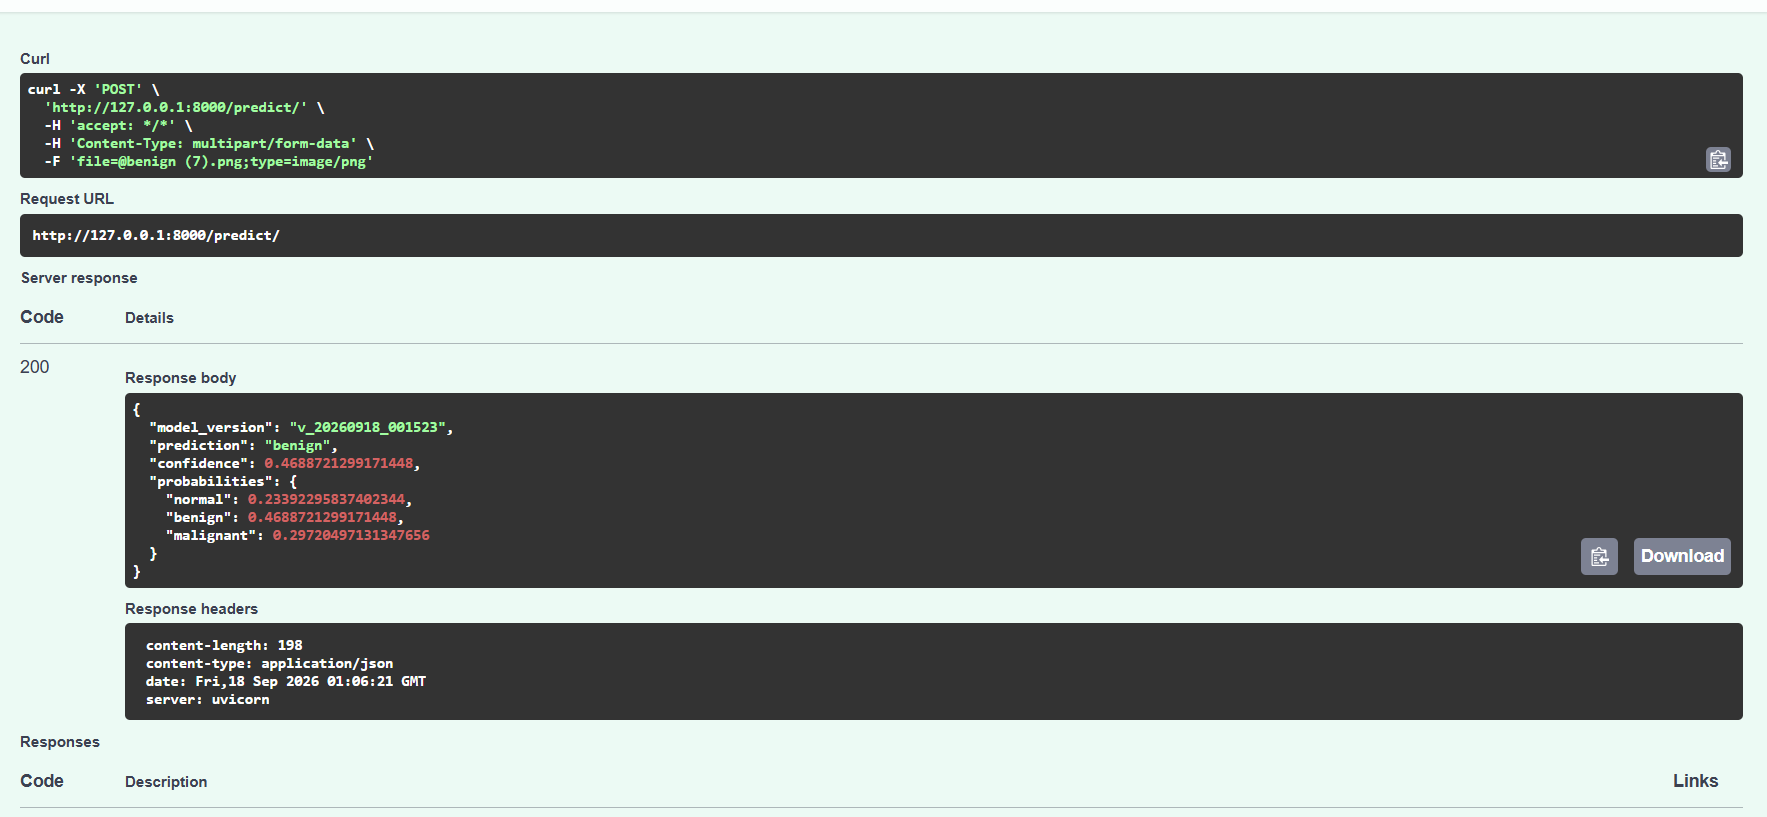

## Section 5 Final reflection



This assignment helped me understand that developing a computer vision model does not end with training and evaluating the model. The model also needs to be packaged, tested, served, and deployed in a reproducible way.

One of the main challenges I encountered was model portability between different environments. My model was trained in Google Colab, while I initially tried to load it in a local environment with different TensorFlow and Keras versions. This caused model loading and compatibility issues. This experience showed me the importance of keeping the software environment consistent when moving a machine learning model from development to deployment.

I also learned how to build an inference pipeline that performs the same preprocessing required by the trained model before making a prediction. This was important because image preprocessing must remain consistent between training and inference.

Another important part of the assignment was learning how to expose the model through a REST API using FastAPI. I was able to send an image to the `/predict/` endpoint and receive a structured JSON response containing the predicted class, confidence, and probabilities.

Finally, containerizing the application with Docker gave me a better understanding of deployment. I learned how to create a Docker image containing the application, dependencies, and model, then run it as a container and expose the FastAPI service locally. Successfully obtaining a prediction through the Dockerized API demonstrated that the complete workflow could operate independently of the original development environment.

Overall, this assignment helped me better understand the transition from a trained computer vision model to a deployable machine learning application. It also showed me the importance of reproducibility, environment management, API design, and containerization in real-world machine learning systems.